# Task 4 — Step 3: GCSC — a Stronger Closed-Set Classifier (+ MLS)

Vaze et al. (2022) argue that open-set performance tracks closed-set accuracy, so a better closed-set classifier scored with the **Maximum Logit Score** is a strong OSR baseline.

**Controlled comparison.** The recipe is *exactly* the Vanilla recipe (architecture, random init, SGD 0.1 / 0.9 / 5e-4, per-step cosine, batch 128, `CLOSED_SET_EPOCHS` = 100 epochs (as in the manual), seed 6304, validation-accuracy selection) with **one change**: `RandAugment(num_ops=2, magnitude=9)` inserted after crop + flip and before `ToTensor`/`Normalize`.

Question tested later (notebook 5): does the augmentation-induced change in closed-set accuracy come with better rejection, in particular for near unknowns? No unknown image is used in this notebook.

In [1]:
%matplotlib inline
import os, sys, json
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if not os.path.isdir(os.path.join(ROOT, 'task4_open_set')) and os.path.isdir('/content/task4_open_set'):
    ROOT = '/content'                    # running on a Colab server (see 0_colab_setup.ipynb)
sys.path.insert(0, ROOT)

import torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

from shared.src.seed import set_seed, SEED
from shared.src.plotting import use_style, PALETTE, NEUTRAL, INK_2, color_of, save_show, bar_labels
from sklearn.manifold import TSNE
from torchvision.transforms import autoaugment, functional as TF
from task4_open_set.src.data import get_cifar10, make_loader, CIFAR10_CLASSES, CIFAR10_ROOT, GCSC_TF, MEAN, STD
from task4_open_set.src.resnet_cifar import ResNetCIFAR
from task4_open_set.src.train import train_closed_set, extract_outputs, CLOSED_SET_EPOCHS

use_style()
set_seed(SEED)
device = torch.device('cuda')
T4 = os.path.join(ROOT, 'task4_open_set')
CKPT, CACHE, RES = [os.path.join(T4, d) for d in ('checkpoints', 'cache', 'results')]
print('GCSC transform:', GCSC_TF)

GCSC transform: Compose(
    RandomCrop(size=(32, 32), padding=4)
    RandomHorizontalFlip(p=0.5)
    RandAugment(num_ops=2, magnitude=9, num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
    ToTensor()
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))
)


## 1. What RandAugment adds
Each row is one training image; columns are independent draws of the full GCSC pipeline (two random ops at magnitude 9 on top of crop + flip).

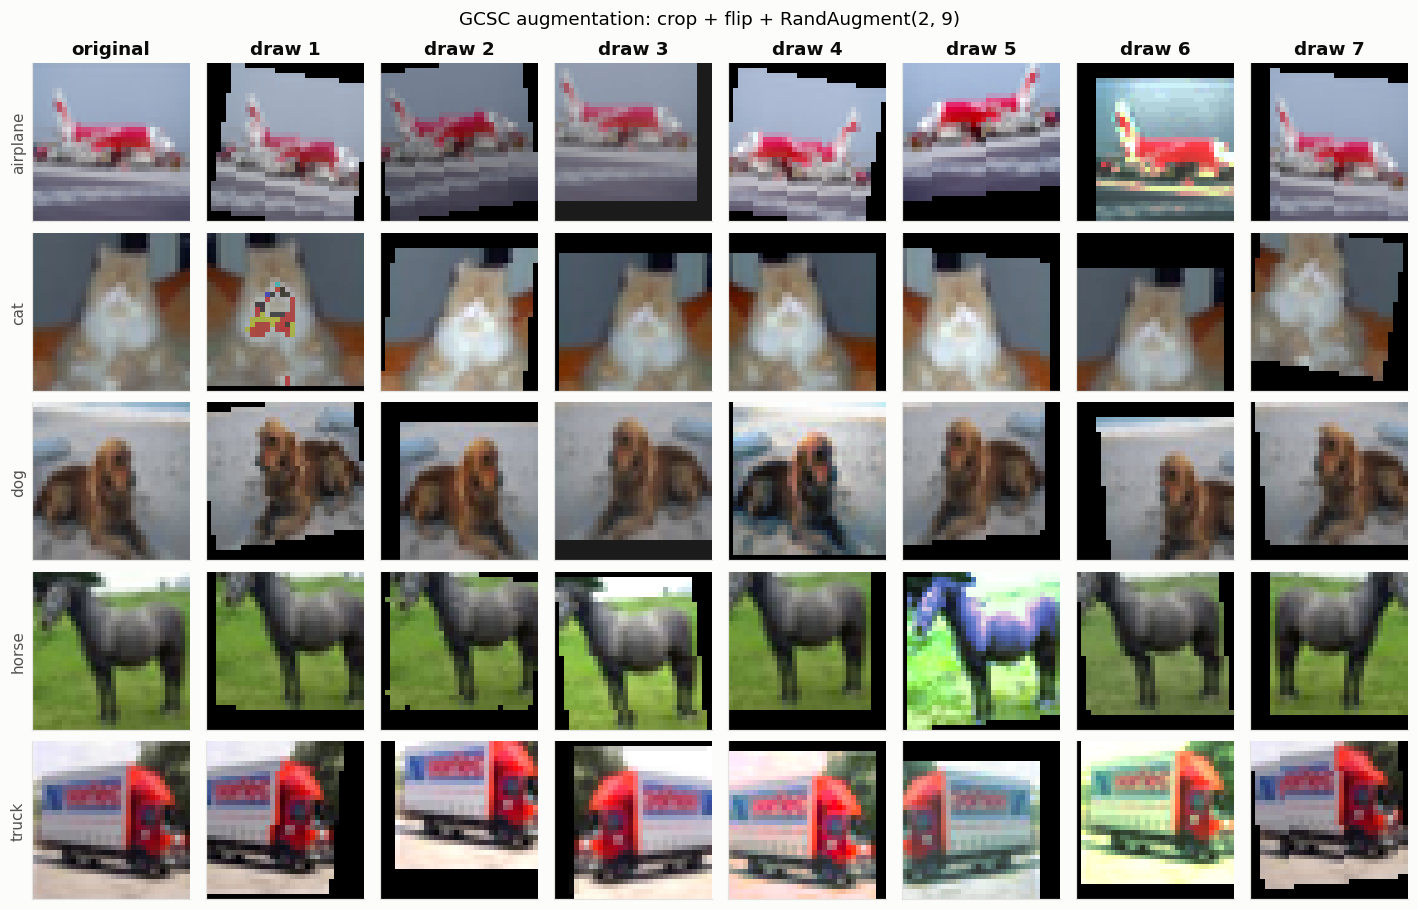

In [2]:
raw = datasets.CIFAR10(CIFAR10_ROOT, train=True)
labels = np.array(raw.targets)
rng = np.random.RandomState(SEED); torch.manual_seed(SEED)
mean, std = torch.tensor(MEAN).view(3, 1, 1), torch.tensor(STD).view(3, 1, 1)
fig, axes = plt.subplots(5, 8, figsize=(13, 8.4))
for r, c in enumerate([0, 3, 5, 7, 9]):
    img = raw[int(rng.choice(np.where(labels == c)[0]))][0]
    axes[r, 0].imshow(img); axes[r, 0].set_ylabel(CIFAR10_CLASSES[c])
    for k in range(1, 8):
        axes[r, k].imshow((GCSC_TF(img) * std + mean).clamp(0, 1).permute(1, 2, 0))
for a in axes.ravel(): a.set_xticks([]); a.set_yticks([]); a.grid(False)
axes[0, 0].set_title('original'); [axes[0, k].set_title(f'draw {k}') for k in range(1, 8)]
fig.suptitle('GCSC augmentation: crop + flip + RandAugment(2, 9)', fontsize=12); fig.tight_layout()
save_show(fig, os.path.join(RES, 'gcsc_randaugment_samples.png'))

### The RandAugment operation pool at magnitude 9
Each RandAugment call picks **2** of these operations uniformly at random (`num_ops=2`), all at magnitude 9 of 31 bins. Signed operations flip their sign with probability ½. Below, each operation is applied alone to the same training image so its effect is visible.

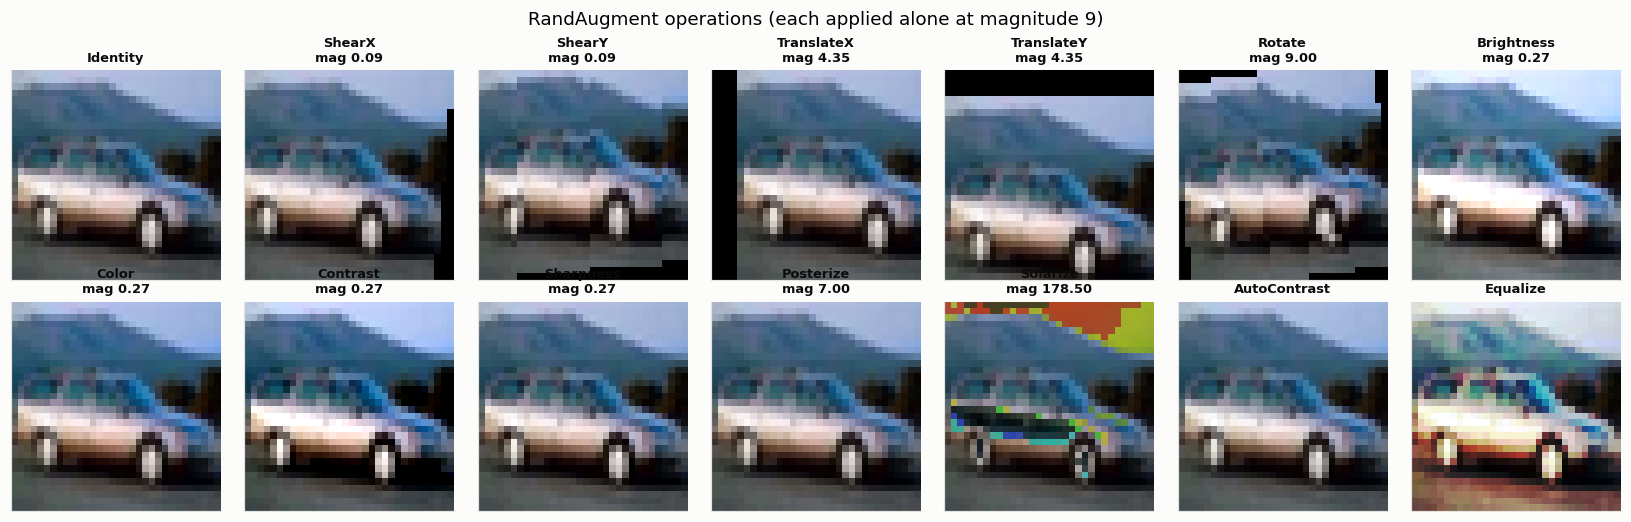

In [3]:
ra = transforms.RandAugment(num_ops=2, magnitude=9)
space = ra._augmentation_space(ra.num_magnitude_bins, (32, 32))
img = raw[int(np.where(labels == 1)[0][0])][0]
fig, axes = plt.subplots(2, 7, figsize=(15, 4.8))
for ax, (op, (mags, signed)) in zip(axes.ravel(), space.items()):
    mag = float(mags[ra.magnitude].item()) if mags.ndim > 0 else 0.0
    out = autoaugment._apply_op(img, op, mag, interpolation=ra.interpolation, fill=None)
    ax.imshow(out); ax.set_title(f'{op}\nmag {mag:.2f}' if mags.ndim > 0 else op, fontsize=8.5); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
for ax in axes.ravel()[len(space):]: ax.axis('off')
fig.suptitle('RandAugment operations (each applied alone at magnitude 9)', fontsize=12); fig.tight_layout()
save_show(fig, os.path.join(RES, 'gcsc_randaugment_ops.png'))

## 2. Train (Vanilla recipe + RandAugment)

In [4]:
FORCE_TRAIN = True
train_aug, train_plain, val_ds, test_ds = get_cifar10(GCSC_TF)
ckpt_path, hist_path = os.path.join(CKPT, 'gcsc.pth'), os.path.join(CKPT, 'gcsc_history.json')
CONFIG = dict(epochs=CLOSED_SET_EPOCHS, lr=0.1, momentum=0.9, weight_decay=5e-4, batch_size=128, schedule='cosine (per step)',
              augmentation='crop+flip+RandAugment(num_ops=2, magnitude=9)', seed=SEED)
if FORCE_TRAIN or not os.path.exists(ckpt_path):
    set_seed(SEED)
    model = ResNetCIFAR(num_classes=10)
    out = train_closed_set(model, make_loader(train_aug, True, 128), make_loader(val_ds, False, 512), device,
                           epochs=CLOSED_SET_EPOCHS, lr=0.1, save_path=ckpt_path, log_every=1)
    hist, best_epoch = out['history'], out['best_epoch']
    json.dump({'config': CONFIG, 'history': hist, 'best_epoch': best_epoch, 'best_val_acc': out['best_val_acc']}, open(hist_path, 'w'), indent=1)
else:
    meta = json.load(open(hist_path)); hist, best_epoch = meta['history'], meta['best_epoch']
model = ResNetCIFAR(num_classes=10).to(device)
model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
print(f'selected epoch {best_epoch} | val acc {max(hist["val_acc"]):.4f}')

mixed precision: torch.float16
ep   1 | loss 2.261 | train acc 0.1922 | val acc 0.3134 * | 19s
ep   2 | loss 1.744 | train acc 0.3461 | val acc 0.3858 * | 18s
ep   3 | loss 1.448 | train acc 0.4733 | val acc 0.5860 * | 18s
ep   4 | loss 1.178 | train acc 0.5813 | val acc 0.6044 * | 18s
ep   5 | loss 1.022 | train acc 0.6399 | val acc 0.6856 * | 18s
ep   6 | loss 0.904 | train acc 0.6829 | val acc 0.7470 * | 18s
ep   7 | loss 0.810 | train acc 0.7167 | val acc 0.7388 | 18s
ep   8 | loss 0.753 | train acc 0.7403 | val acc 0.7488 * | 18s
ep   9 | loss 0.722 | train acc 0.7483 | val acc 0.7684 * | 18s
ep  10 | loss 0.688 | train acc 0.7614 | val acc 0.7272 | 18s
ep  11 | loss 0.663 | train acc 0.7702 | val acc 0.7788 * | 18s
ep  12 | loss 0.639 | train acc 0.7802 | val acc 0.8012 * | 18s
ep  13 | loss 0.620 | train acc 0.7864 | val acc 0.7830 | 18s
ep  14 | loss 0.604 | train acc 0.7932 | val acc 0.8120 * | 18s
ep  15 | loss 0.579 | train acc 0.8004 | val acc 0.8018 | 18s
ep  16 | loss 0.5

## 3. Training dynamics vs Vanilla

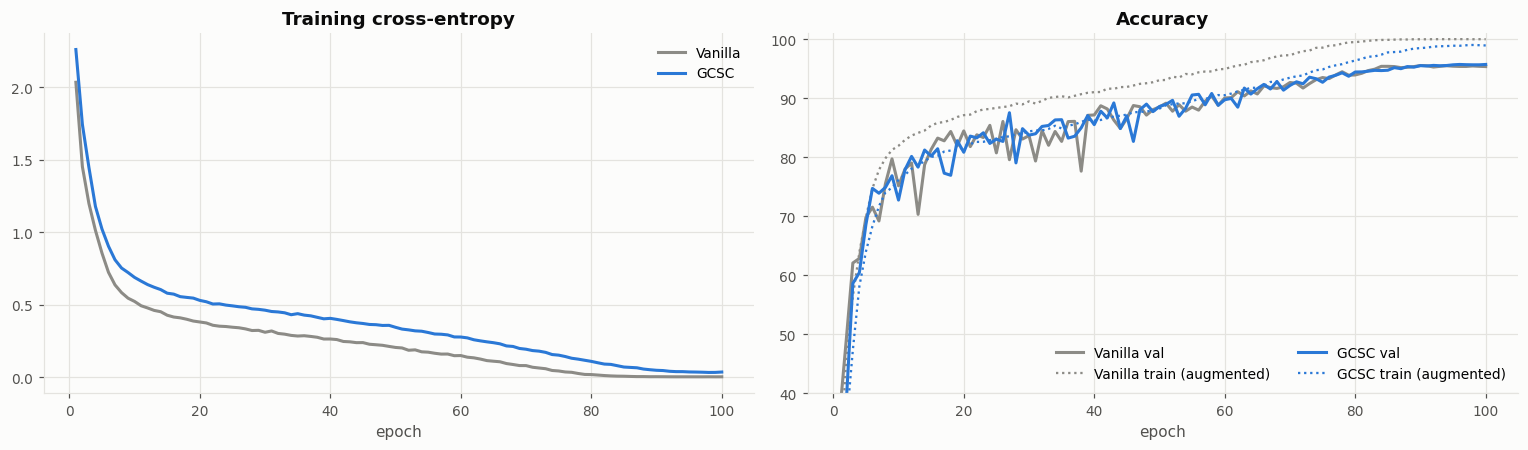

In [5]:
van = json.load(open(os.path.join(CKPT, 'vanilla_history.json')))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.2))
for name, h in [('Vanilla', van['history']), ('GCSC', hist)]:
    e = np.arange(1, len(h['train_loss']) + 1)
    a1.plot(e, h['train_loss'], color=color_of(name), label=name)
    a2.plot(e, 100 * np.array(h['val_acc']), color=color_of(name), label=f'{name} val')
    a2.plot(e, 100 * np.array(h['train_acc']), color=color_of(name), ls=':', lw=1.5, label=f'{name} train (augmented)')
a1.set_title('Training cross-entropy'); a1.set_xlabel('epoch'); a1.legend()
a2.set_ylim(40, 101); a2.set_title('Accuracy'); a2.set_xlabel('epoch'); a2.legend(ncol=2)
fig.tight_layout(); save_show(fig, os.path.join(RES, 'gcsc_vs_vanilla_training.png'))

## 4. Closed-set accuracy and cached outputs

In [6]:
loaders = {'train': make_loader(train_plain, False, 512), 'val': make_loader(val_ds, False, 512), 'test': make_loader(test_ds, False, 512)}
outs = {k: extract_outputs(model, l, device) for k, l in loaders.items()}
np.savez_compressed(os.path.join(CACHE, 'gcsc_known.npz'), **{f'{k}_{f}': v for k, o in outs.items() for f, v in o.items()})
csa = (outs['test']['logits'].argmax(1) == outs['test']['labels']).mean()
json.dump({'csa': float(csa)}, open(os.path.join(RES, 'gcsc_csa.json'), 'w'))
v = np.load(os.path.join(CACHE, 'vanilla_known.npz'))
csa_v = (v['test_logits'].argmax(1) == v['test_labels']).mean()
print(f"CSA  Vanilla {100*csa_v:.2f}%  ->  GCSC {100*csa:.2f}%  ({100*(csa-csa_v):+.2f} pp)")

CSA  Vanilla 94.81%  ->  GCSC 94.95%  (+0.14 pp)


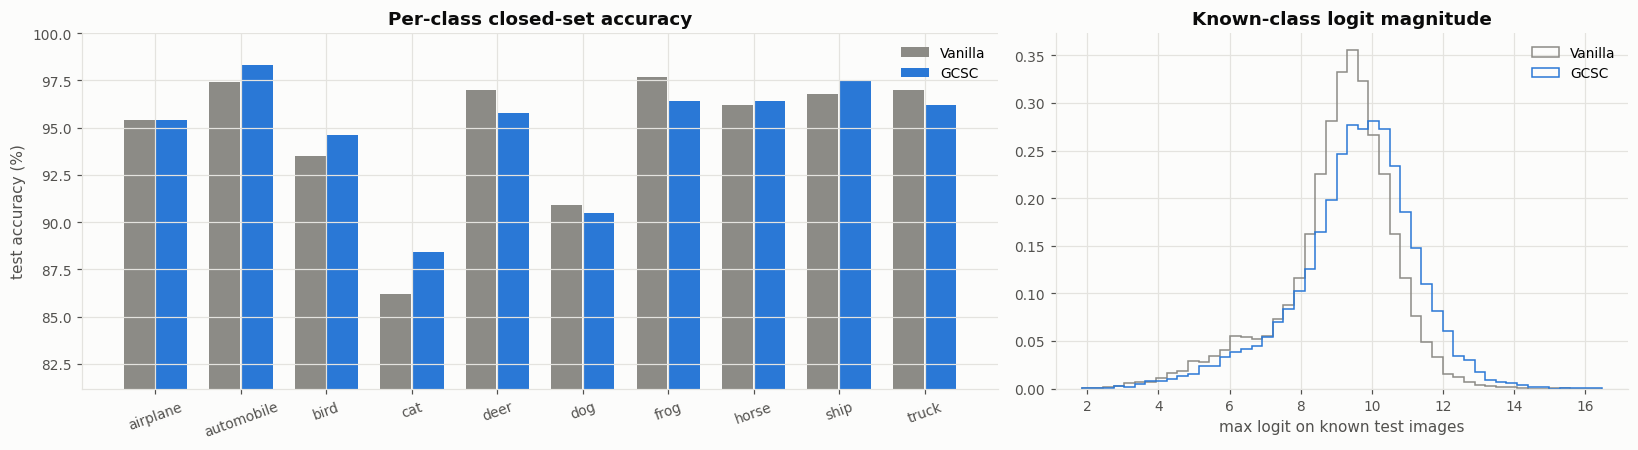

In [7]:
def per_class(logits, labels):
    p = logits.argmax(1); return np.array([(p[labels == c] == c).mean() for c in range(10)]) * 100
pv, pg = per_class(v['test_logits'], v['test_labels']), per_class(outs['test']['logits'], outs['test']['labels'])
mls_v, mls_g = v['test_logits'].max(1), outs['test']['logits'].max(1)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 4.2), gridspec_kw={'width_ratios': [1.6, 1]})
x = np.arange(10); w = 0.38
b1 = a1.bar(x - w / 2, pv, w * 0.95, color=color_of('Vanilla'), label='Vanilla')
b2 = a1.bar(x + w / 2, pg, w * 0.95, color=color_of('GCSC'), label='GCSC')
a1.set_ylim(min(pv.min(), pg.min()) - 5, 100); a1.set_xticks(x); a1.set_xticklabels(CIFAR10_CLASSES, rotation=20)
a1.set_ylabel('test accuracy (%)'); a1.set_title('Per-class closed-set accuracy'); a1.legend()
bins = np.linspace(min(mls_v.min(), mls_g.min()), max(mls_v.max(), mls_g.max()), 50)
a2.hist(mls_v, bins=bins, histtype='step', lw=2, color=color_of('Vanilla'), label='Vanilla', density=True)
a2.hist(mls_g, bins=bins, histtype='step', lw=2, color=color_of('GCSC'), label='GCSC', density=True)
a2.set_xlabel('max logit on known test images'); a2.set_title('Known-class logit magnitude'); a2.legend()
fig.tight_layout(); save_show(fig, os.path.join(RES, 'gcsc_closed_set_comparison.png'))

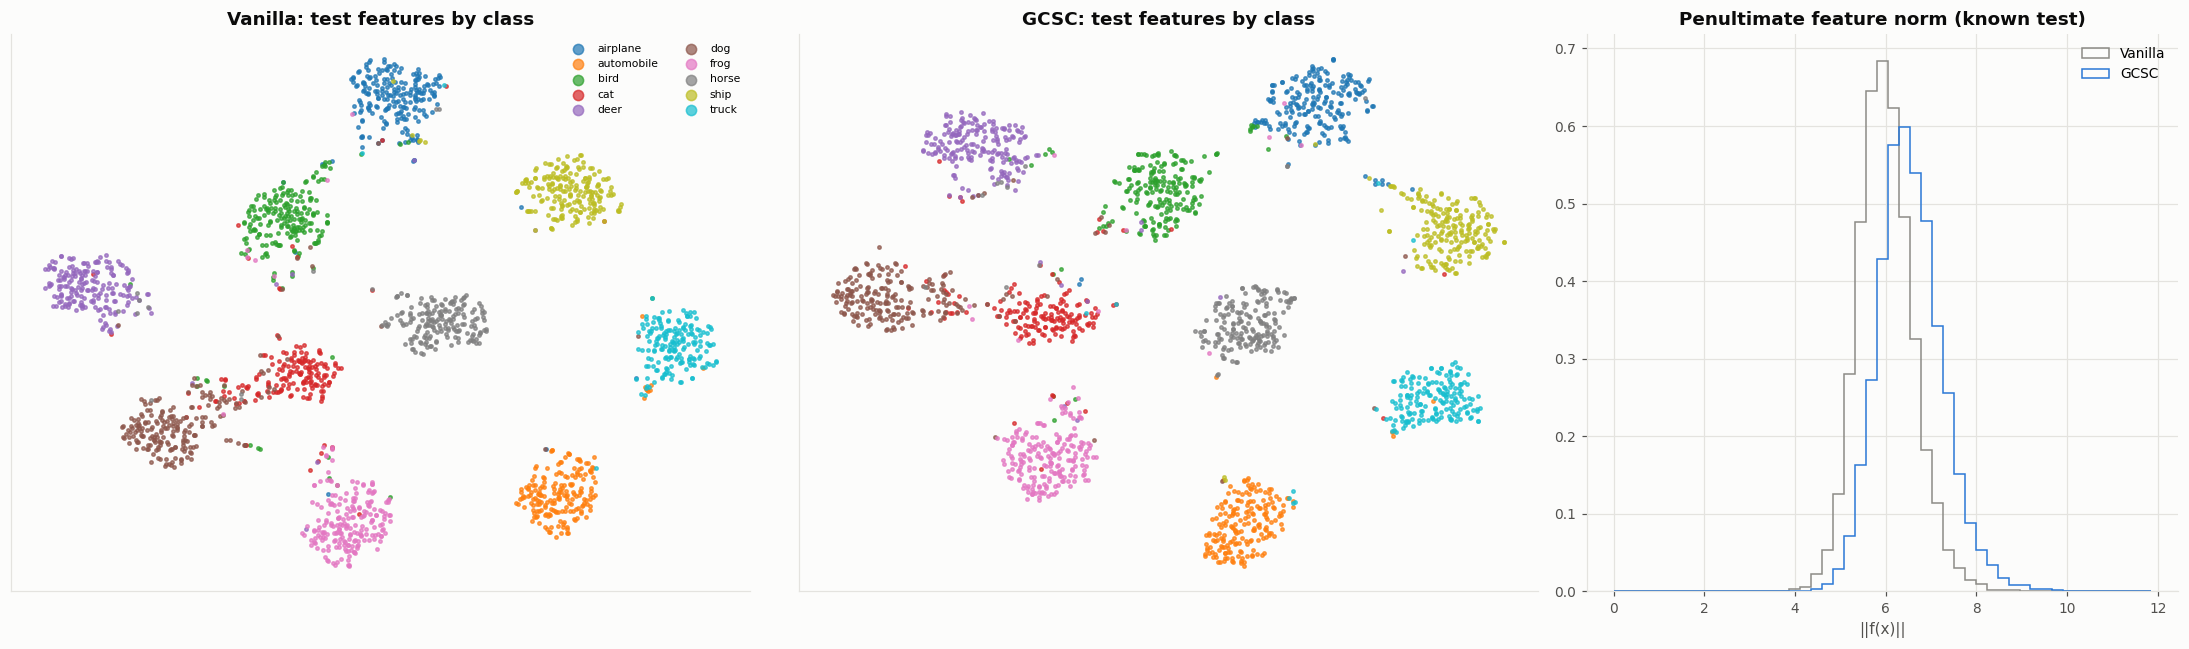

In [8]:
# Known-class feature geometry and logit/feature magnitude: Vanilla vs GCSC (known test only)
sel = np.random.RandomState(SEED).choice(len(outs['test']['labels']), 2000, replace=False); yk = outs['test']['labels'][sel]
cmap10 = plt.get_cmap('tab10')
fig, axes = plt.subplots(1, 3, figsize=(20, 6), gridspec_kw={'width_ratios': [1, 1, 0.8]})
for ax, (name, feats) in zip(axes[:2], [('Vanilla', v['test_feats']), ('GCSC', outs['test']['feats'])]):
    E = TSNE(n_components=2, perplexity=30, init='pca', random_state=SEED).fit_transform(feats[sel])
    for c in range(10):
        s = yk == c; ax.scatter(E[s, 0], E[s, 1], s=5, alpha=0.7, color=cmap10(c), label=CIFAR10_CLASSES[c])
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(f'{name}: test features by class')
axes[0].legend(markerscale=3, fontsize=7, ncol=2)
bins = np.linspace(0, max(np.linalg.norm(v['test_feats'], axis=1).max(), np.linalg.norm(outs['test']['feats'], axis=1).max()), 50)
for name, feats in [('Vanilla', v['test_feats']), ('GCSC', outs['test']['feats'])]:
    axes[2].hist(np.linalg.norm(feats, axis=1), bins=bins, histtype='step', lw=2, color=color_of(name), density=True, label=name)
axes[2].set_xlabel('||f(x)||'); axes[2].set_title('Penultimate feature norm (known test)'); axes[2].legend()
fig.tight_layout(); save_show(fig, os.path.join(RES, 'gcsc_vs_vanilla_features.png'))

## 5. MLS operating point on known data only
The rejection threshold is fixed here from the CIFAR-10 validation set (95th percentile of $u_{\text{MLS}}=-\max_k z_k$), so every known validation image with $u\le\tau$ is accepted. The known *test* acceptance rate checks the calibration. Unknowns are evaluated in notebooks 2 and 5.

In [9]:
u_val, u_test = -outs['val']['logits'].max(1), -outs['test']['logits'].max(1)
tau = np.percentile(u_val, 95)
print(f"GCSC MLS threshold tau = {tau:.3f} | known val accept {100*(u_val<=tau).mean():.1f}% | known test accept {100*(u_test<=tau).mean():.1f}%")

GCSC MLS threshold tau = -6.219 | known val accept 95.0% | known test accept 94.9%
